# Лабораторная работа: Линейное Программирование в Задачах Оптимизации

In [2]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Решение задачи оптимизации производства


c = [-8000, -12000]

# Ограничения-неравенства A_ub @ x <= b_ub
A_ub = [
    [2, 3],
    [4, 6],
    [1, 2]
]
b_ub = [240, 480, 150]


bounds = [(0, None), (0, None)]


result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print("=== Задача оптимизации производства электроники ===")
print(f"Статус: {result.message}")
print()
print("Оптимальный план производства:")
print(f"  Смартфоны (x₁): {result.x[0]:.0f} шт.")
print(f"  Планшеты   (x₂): {result.x[1]:.0f} шт.")
print()
print(f"Максимальная прибыль: {-result.fun:,.0f} руб.")
print()

print("Использование ресурсов:")
resources_used = A_ub @ result.x
for i, (used, total, name) in enumerate(zip(resources_used, b_ub,
                                            ["Процессорное время (часы)",
                                             "Оперативная память (ГБ)",
                                             "Аккумуляторы (шт.)"])):
    print(f"  {name}: {used:.0f} / {total} (использовано {used/total*100:.1f}%)")
    if abs(used - total) < 1e-6:
        print(f"    → Ресурс используется ПОЛНОСТЬЮ (активное ограничение)")
    else:
        print(f"    → Остаток: {total - used:.0f} (неиспользованный ресурс)")

print()
print("=" * 60)

=== Задача оптимизации производства электроники ===
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Оптимальный план производства:
  Смартфоны (x₁): 30 шт.
  Планшеты   (x₂): 60 шт.

Максимальная прибыль: 960,000 руб.

Использование ресурсов:
  Процессорное время (часы): 240 / 240 (использовано 100.0%)
    → Ресурс используется ПОЛНОСТЬЮ (активное ограничение)
  Оперативная память (ГБ): 480 / 480 (использовано 100.0%)
    → Ресурс используется ПОЛНОСТЬЮ (активное ограничение)
  Аккумуляторы (шт.): 150 / 150 (использовано 100.0%)
    → Ресурс используется ПОЛНОСТЬЮ (активное ограничение)



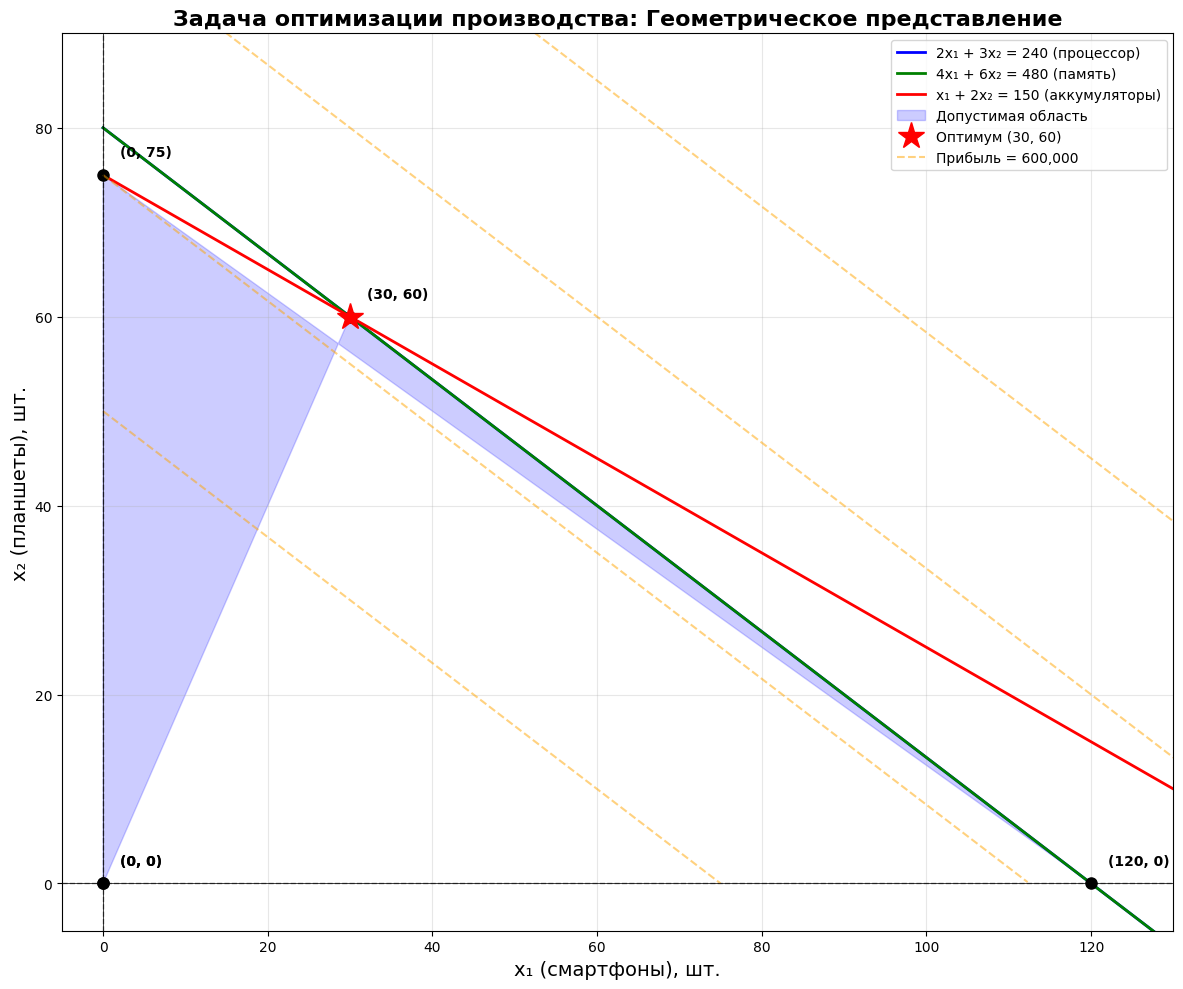

In [3]:
# Геометрическая визуализация

fig, ax = plt.subplots(figsize=(12, 10))

# Диапазон значений
x1_max = 160
x1 = np.linspace(0, x1_max, 400)

# Границы ограничений: выражаем x₂ через x₁
# 1) Процессорное время: 2x₁ + 3x₂ <= 240 => x₂ <= (240 - 2x₁)/3
x2_constraint1 = (240 - 2*x1) / 3
# 2) Память: 4x₁ + 6x₂ <= 480 => x₂ <= (480 - 4x₁)/6
x2_constraint2 = (480 - 4*x1) / 6
# 3) Аккумуляторы: x₁ + 2x₂ <= 150 => x₂ <= (150 - x₁)/2
x2_constraint3 = (150 - x1) / 2

# Построение прямых ограничений
ax.plot(x1, x2_constraint1, 'b-', linewidth=2, label='2x₁ + 3x₂ = 240 (процессор)')
ax.plot(x1, x2_constraint2, 'g-', linewidth=2, label='4x₁ + 6x₂ = 480 (память)')
ax.plot(x1, x2_constraint3, 'r-', linewidth=2, label='x₁ + 2x₂ = 150 (аккумуляторы)')
ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)

vertices = []

# (0, 0)
vertices.append([0, 0])

vertices.append([0, 75])

vertices.append([120, 0])

vertices.append([30, 60])

vertices.append([0, 0])


polygon = Polygon(vertices, closed=True, alpha=0.2, color='blue', label='Допустимая область')
ax.add_patch(polygon)


for v in vertices:
    ax.plot(v[0], v[1], 'ko', markersize=8)
    ax.text(v[0]+2, v[1]+2, f'({v[0]}, {v[1]})', fontsize=10, fontweight='bold')


x_opt = result.x
ax.plot(x_opt[0], x_opt[1], 'r*', markersize=20, label=f'Оптимум ({x_opt[0]:.0f}, {x_opt[1]:.0f})')

profit_levels = [600000, 900000, 1200000, 1500000]
colors = ['orange', 'orange', 'orange', 'orange']
for level, color in zip(profit_levels, colors):

    x2_profit = (level - 8000*x1) / 12000

    mask = (x2_profit >= 0) & (x2_profit <= x1_max*0.8)
    if np.any(mask):
        ax.plot(x1[mask], x2_profit[mask], 'orange', linewidth=1.5, linestyle='--',
                alpha=0.5, label=f'Прибыль = {level:,}' if level == profit_levels[0] else "")


ax.set_xlim(-5, 130)
ax.set_ylim(-5, 90)
ax.set_xlabel('x₁ (смартфоны), шт.', fontsize=14)
ax.set_ylabel('x₂ (планшеты), шт.', fontsize=14)
ax.set_title('Задача оптимизации производства: Геометрическое представление', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('task1_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# 2.4. Решение транспортной задачи

import numpy as np
from scipy.optimize import linprog

c = [8, 6, 10, 9, 7, 5]
A_eq = [
    [1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 1],
    [1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 1]
]

b_eq = [150, 250, 120, 180, 100]

bounds = [(0, None)] * 6

result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')


print("=== Транспортная задача снабжения военных баз ===")
print(f"Статус: {result.message}")
print()

x11, x12, x13, x21, x22, x23 = result.x

print("Оптимальный план перевозок (тонн):")
print(f"  Склад 1 → База Альфа: {x11:.0f} тонн")
print(f"  Склад 1 → База Бета:  {x12:.0f} тонн")
print(f"  Склад 1 → База Гамма: {x13:.0f} тонн")
print(f"  Склад 2 → База Альфа: {x21:.0f} тонн")
print(f"  Склад 2 → База Бета:  {x22:.0f} тонн")
print(f"  Склад 2 → База Гамма: {x23:.0f} тонн")
print()

print("Минимальные транспортные расходы:")
print(f"  Z = {result.fun:.0f} усл. ед.")
print()

print("Проверка ограничений:")
print(f"  Склад 1: {x11 + x12 + x13:.0f} = 150 {'✓' if abs(x11 + x12 + x13 - 150) < 1e-6 else '✗'}")
print(f"  Склад 2: {x21 + x22 + x23:.0f} = 250 {'✓' if abs(x21 + x22 + x23 - 250) < 1e-6 else '✗'}")
print(f"  База Альфа: {x11 + x21:.0f} = 120 {'✓' if abs(x11 + x21 - 120) < 1e-6 else '✗'}")
print(f"  База Бета: {x12 + x22:.0f} = 180 {'✓' if abs(x12 + x22 - 180) < 1e-6 else '✗'}")
print(f"  База Гамма: {x13 + x23:.0f} = 100 {'✓' if abs(x13 + x23 - 100) < 1e-6 else '✗'}")

print("=" * 60)

=== Транспортная задача снабжения военных баз ===
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Оптимальный план перевозок (тонн):
  Склад 1 → База Альфа: 0 тонн
  Склад 1 → База Бета:  150 тонн
  Склад 1 → База Гамма: 0 тонн
  Склад 2 → База Альфа: 120 тонн
  Склад 2 → База Бета:  30 тонн
  Склад 2 → База Гамма: 100 тонн

Минимальные транспортные расходы:
  Z = 2690 усл. ед.

Проверка ограничений:
  Склад 1: 150 = 150 ✓
  Склад 2: 250 = 250 ✓
  База Альфа: 120 = 120 ✓
  База Бета: 180 = 180 ✓
  База Гамма: 100 = 100 ✓


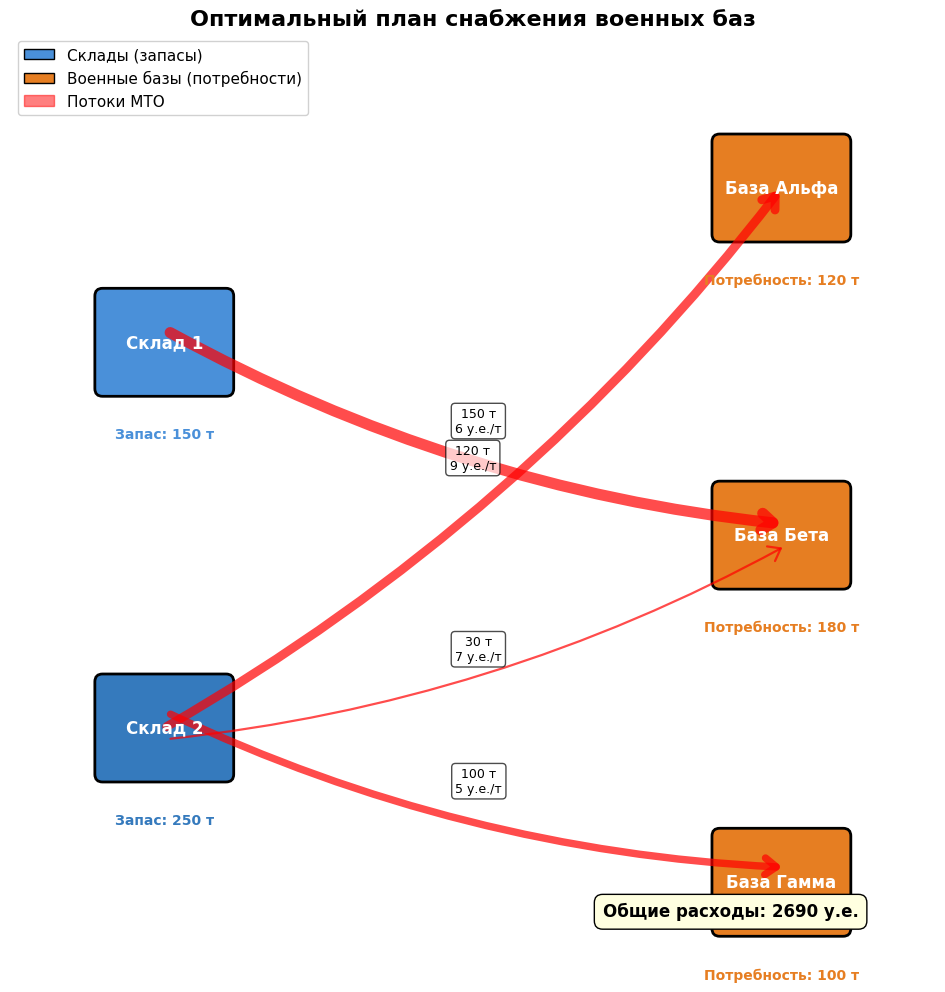

In [5]:
# 2.5. Визуализация сетевой диаграммы


import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))


warehouses = {'Склад 1': (2, 8), 'Склад 2': (2, 3)}
bases = {'Альфа': (10, 10), 'Бета': (10, 5.5), 'Гамма': (10, 1)}


warehouse_colors = {'Склад 1': '#4A90D9', 'Склад 2': '#357ABD'}
base_colors = {'Альфа': '#E67E22', 'Бета': '#E67E22', 'Гамма': '#E67E22'}


for name, (x, y) in warehouses.items():
    rect = FancyBboxPatch((x-0.8, y-0.6), 1.6, 1.2,
                          boxstyle="round,pad=0.1",
                          facecolor=warehouse_colors[name],
                          edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, name, ha='center', va='center', fontsize=12, fontweight='bold', color='white')


    if name == 'Склад 1':
        ax.text(x, y-1.2, 'Запас: 150 т', ha='center', va='center', fontsize=10, color='#4A90D9', fontweight='bold')
    else:
        ax.text(x, y-1.2, 'Запас: 250 т', ha='center', va='center', fontsize=10, color='#357ABD', fontweight='bold')

for name, (x, y) in bases.items():
    rect = FancyBboxPatch((x-0.8, y-0.6), 1.6, 1.2,
                          boxstyle="round,pad=0.1",
                          facecolor=base_colors[name],
                          edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, f'База {name}', ha='center', va='center', fontsize=12, fontweight='bold', color='white')


    needs = {'Альфа': 120, 'Бета': 180, 'Гамма': 100}
    ax.text(x, y-1.2, f'Потребность: {needs[name]} т', ha='center', va='center', fontsize=10, color='#E67E22', fontweight='bold')


flows = [
    ('Склад 1', 'Альфа', x11, 8, 'red'),
    ('Склад 1', 'Бета', x12, 6, 'red'),
    ('Склад 1', 'Гамма', x13, 10, 'red'),
    ('Склад 2', 'Альфа', x21, 9, 'red'),
    ('Склад 2', 'Бета', x22, 7, 'red'),
    ('Склад 2', 'Гамма', x23, 5, 'red'),
]

max_flow = max([f[2] for f in flows]) if any([f[2] > 0 for f in flows]) else 1
arrow_width_scale = 8

for from_node, to_node, flow, cost, color in flows:
    if flow > 0:
        start = warehouses[from_node]
        end = bases[to_node]


        width = max(1, (flow / max_flow) * arrow_width_scale)

        dx = end[0] - start[0]
        dy = end[1] - start[1]
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:

            nx = dx / length
            ny = dy / length

            perp_x = -ny
            perp_y = nx


            offset = 0
            if from_node == 'Склад 1' and to_node == 'Бета':
                offset = 0.3
            elif from_node == 'Склад 2' and to_node == 'Бета':
                offset = -0.3
            elif from_node == 'Склад 2' and to_node == 'Гамма':
                offset = 0.4


            start_offset = (start[0] + perp_x * offset * 0.5, start[1] + perp_y * offset * 0.5)
            end_offset = (end[0] + perp_x * offset * 0.5, end[1] + perp_y * offset * 0.5)


            arrow = FancyArrowPatch(start_offset, end_offset,
                                   arrowstyle='->,head_width=6,head_length=8',
                                   color=color,
                                   linewidth=width,
                                   alpha=0.7,
                                   connectionstyle='arc3,rad=0.1')
            ax.add_patch(arrow)


            mid_x = (start_offset[0] + end_offset[0]) / 2 + perp_x * offset * 0.3
            mid_y = (start_offset[1] + end_offset[1]) / 2 + perp_y * offset * 0.3
            ax.text(mid_x, mid_y, f'{flow:.0f} т\n{cost} у.е./т',
                   ha='center', va='center', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Оптимальный план снабжения военных баз', fontsize=16, fontweight='bold')

legend_elements = [
    mpatches.Patch(facecolor='#4A90D9', edgecolor='black', label='Склады (запасы)'),
    mpatches.Patch(facecolor='#E67E22', edgecolor='black', label='Военные базы (потребности)'),
    mpatches.Patch(facecolor='red', edgecolor='red', alpha=0.5, label='Потоки МТО'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

ax.text(11, 0.5, f'Общие расходы: {result.fun:.0f} у.е.',
        ha='right', va='bottom', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='black'))

plt.tight_layout()
plt.savefig('task2_network.png', dpi=150, bbox_inches='tight')
plt.show()